# 📊 Notebook 1: Inmate Processing Delay Prediction
### Predictive Analytics for Criminal Justice Reform
**Author:** Esther Ali | M.S. Business Analytics – University of Louisville  
**Role:** Senior Corrections Data Analyst & Technician – Louisville Metro Department of Corrections  
**Dataset:** Inmate Booking Records – Kentucky Correctional System (2024)

---

## Objective
Predict the number of days an inmate will be held before release using information available at booking time. Early prediction of processing time supports:
- Proactive resource and bed allocation
- Reduction of unnecessary detention
- Improved inter-agency coordination

## Dataset Description
| Feature | Description |
|---|---|
| `court_delay_days` | Scheduling delay before court appearance (0–9 days) |
| `charge_type` | Misdemeanor or Felony |
| `county` | Boone, Fayette, Jefferson, or Kenton |
| `holds` | Active detainer hold (0=No, 1=Yes) |
| `housing_unit` | Assigned unit (Dorm A, Dorm B, Medical) |
| `custody_level` | Security classification (Min, Medium, Max) |
| `agency` | Booking agency (Local, Sheriff, Federal) |
| `prior_offenses` | Number of prior offenses (0–5) |
| `sentence_days` | Sentence length in days |
| `credit_days` | Days already credited toward sentence |
| `time_served` | Days already served |
| `release_type` | Completion, Parole, or Transfer |
| `release_days` | **TARGET** — days until release |

## Methodology
1. Exploratory Data Analysis (EDA)
2. Feature Engineering & Encoding
3. Model Training: Linear Regression · Ridge · Random Forest · XGBoost
4. Evaluation: MAE, RMSE, R², Cross-Validation
5. Feature Importance & Policy Insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})
print("✅ Libraries loaded")


✅ Libraries loaded


## 1. Load & Inspect Data

In [2]:
df = pd.read_excel('../data/inmate_dashboard.xlsx', sheet_name='Dataset')
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Shape: 100 rows × 17 columns

,Inmate_id,booking_time,charge_type,court_delay_days,county,holds,release_days,housing_unit,custody_level,agency,prior_offenses,sentence_days,credit_days,time_served,release_type,delay_flag,risk_flag
0,1012300,2024-02-21,Misdemeanor,8,Boone,0,17,Medical,Min,Local,1,74,38,39,Parole,1,0
1,1012301,2024-04-02,Felony,4,Fayette,1,11,Medical,Max,Local,2,275,32,15,Transfer,1,1
2,1012302,2024-01-15,Misdemeanor,0,Jefferson,1,7,Medical,Medium,Local,5,324,35,239,Transfer,1,1
3,1012303,2024-03-12,Felony,2,Jefferson,1,8,Dorm B,Medium,Sheriff,4,203,50,44,Transfer,1,1
4,1012304,2024-03-01,Misdemeanor,9,Boone,1,17,Medical,Medium,Federal,4,139,30,107,Parole,1,1


In [3]:
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:")
df.describe(include='all').round(2)


Data Types:
 Inmate_id                    int64
booking_time        datetime64[ns]
charge_type                 object
court_delay_days             int64
county                      object
holds                        int64
release_days                 int64
housing_unit                object
custody_level               object
agency                      object
prior_offenses               int64
sentence_days                int64
credit_days                  int64
time_served                  int64
release_type                object
delay_flag                   int64
risk_flag                    int64
dtype: object

Missing Values:
 Inmate_id           0
booking_time        0
charge_type         0
court_delay_days    0
county              0
holds               0
release_days        0
housing_unit        0
custody_level       0
agency              0
prior_offenses      0
sentence_days       0
credit_days         0
time_served         0
release_type        0
delay_flag          0
risk_fla

,Inmate_id,booking_time,charge_type,court_delay_days,county,holds,release_days,housing_unit,custody_level,agency,prior_offenses,sentence_days,credit_days,time_served,release_type,delay_flag,risk_flag
count,100.00,100,100,100.00,100,100.00,100.00,100,100,100,100.00,100.00,100.00,100.00,100,100.00,100.00
unique,NaN,NaN,2,NaN,4,NaN,NaN,3,3,3,NaN,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,Misdemeanor,NaN,Jefferson,NaN,NaN,Medical,Max,Federal,NaN,NaN,NaN,NaN,Completion,NaN,NaN
freq,NaN,NaN,53,NaN,31,NaN,NaN,35,42,38,NaN,NaN,NaN,NaN,35,NaN,NaN
mean,1012349.50,2024-02-20 12:57:36,NaN,4.03,NaN,0.48,9.38,NaN,NaN,NaN,2.54,210.76,33.57,120.78,NaN,0.84,0.83
min,1012300.00,2024-01-02 00:00:00,NaN,0.00,NaN,0.00,1.00,NaN,NaN,NaN,0.00,30.00,0.00,0.00,NaN,0.00,0.00
25%,1012324.75,2024-01-23 12:00:00,NaN,1.75,NaN,0.00,6.75,NaN,NaN,NaN,1.00,141.00,15.75,33.00,NaN,1.00,1.00
50%,1012349.50,2024-02-23 00:00:00,NaN,4.00,NaN,0.00,10.00,NaN,NaN,NaN,2.50,204.00,32.50,97.50,NaN,1.00,1.00
75%,1012374.25,2024-03-16 12:00:00,NaN,7.00,NaN,1.00,12.00,NaN,NaN,NaN,4.00,285.25,43.00,179.25,NaN,1.00,1.00
max,1012399.00,2024-04-09 00:00:00,NaN,9.00,NaN,1.00,17.00,NaN,NaN,NaN,5.00,363.00,200.00,363.00,NaN,1.00,1.00


## 2. Exploratory Data Analysis

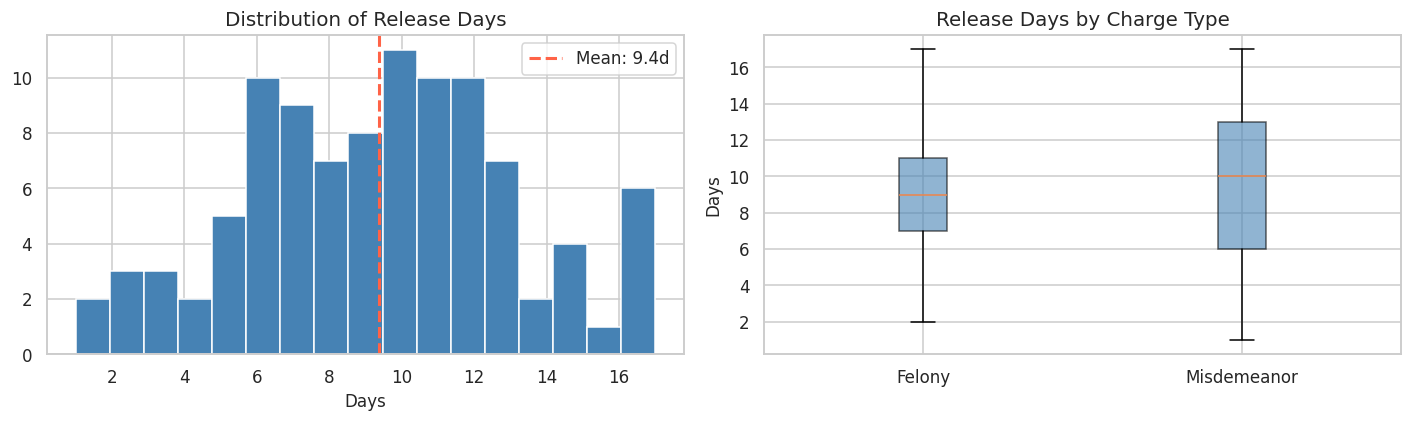

Avg release days — Felony: 9.0 | Misdemeanor: 9.7


In [4]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['release_days'], bins=17, color='steelblue', edgecolor='white')
axes[0].axvline(df['release_days'].mean(), color='tomato', linestyle='--', lw=2,
                label=f"Mean: {df['release_days'].mean():.1f}d")
axes[0].set_title('Distribution of Release Days'); axes[0].set_xlabel('Days'); axes[0].legend()

axes[1].boxplot([df.loc[df['charge_type']=='Felony','release_days'],
                 df.loc[df['charge_type']=='Misdemeanor','release_days']],
                labels=['Felony','Misdemeanor'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Release Days by Charge Type'); axes[1].set_ylabel('Days')

plt.tight_layout()
plt.savefig('../diagrams/nb1_release_dist.png', bbox_inches='tight')
plt.show()
print(f"Avg release days — Felony: {df[df.charge_type=='Felony'].release_days.mean():.1f} | Misdemeanor: {df[df.charge_type=='Misdemeanor'].release_days.mean():.1f}")


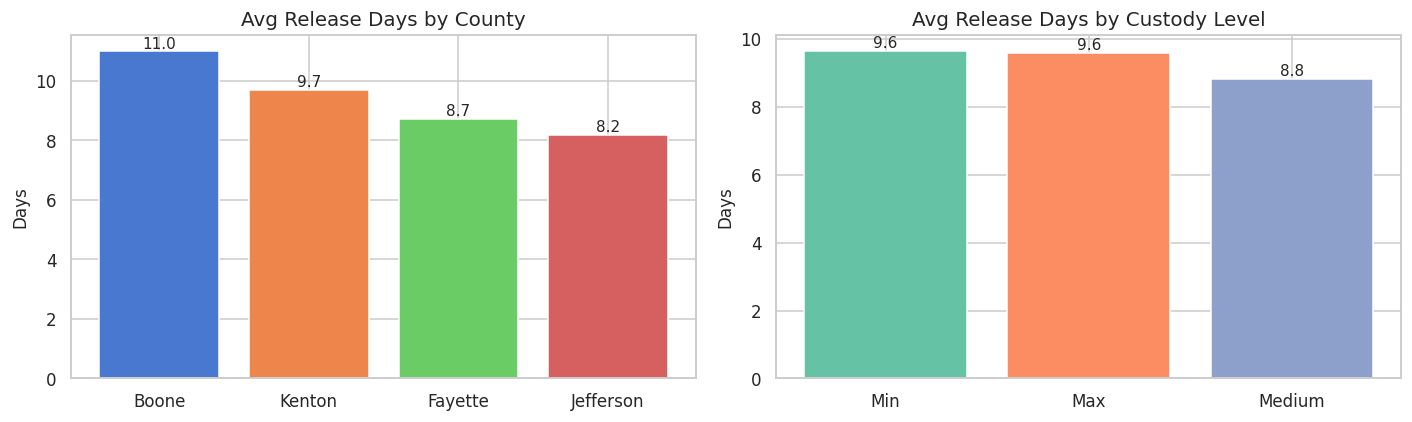

In [5]:
# County and custody-level analysis
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

county_avg = df.groupby('county')['release_days'].mean().sort_values(ascending=False)
axes[0].bar(county_avg.index, county_avg.values, color=sns.color_palette("muted",4), edgecolor='white')
for i,(k,v) in enumerate(county_avg.items()):
    axes[0].text(i, v+0.1, f'{v:.1f}', ha='center', fontsize=10)
axes[0].set_title('Avg Release Days by County'); axes[0].set_ylabel('Days')

custody_avg = df.groupby('custody_level')['release_days'].mean().sort_values(ascending=False)
axes[1].bar(custody_avg.index, custody_avg.values, color=sns.color_palette("Set2",3), edgecolor='white')
for i,(k,v) in enumerate(custody_avg.items()):
    axes[1].text(i, v+0.1, f'{v:.1f}', ha='center', fontsize=10)
axes[1].set_title('Avg Release Days by Custody Level'); axes[1].set_ylabel('Days')

plt.tight_layout()
plt.savefig('../diagrams/nb1_county_custody.png', bbox_inches='tight')
plt.show()


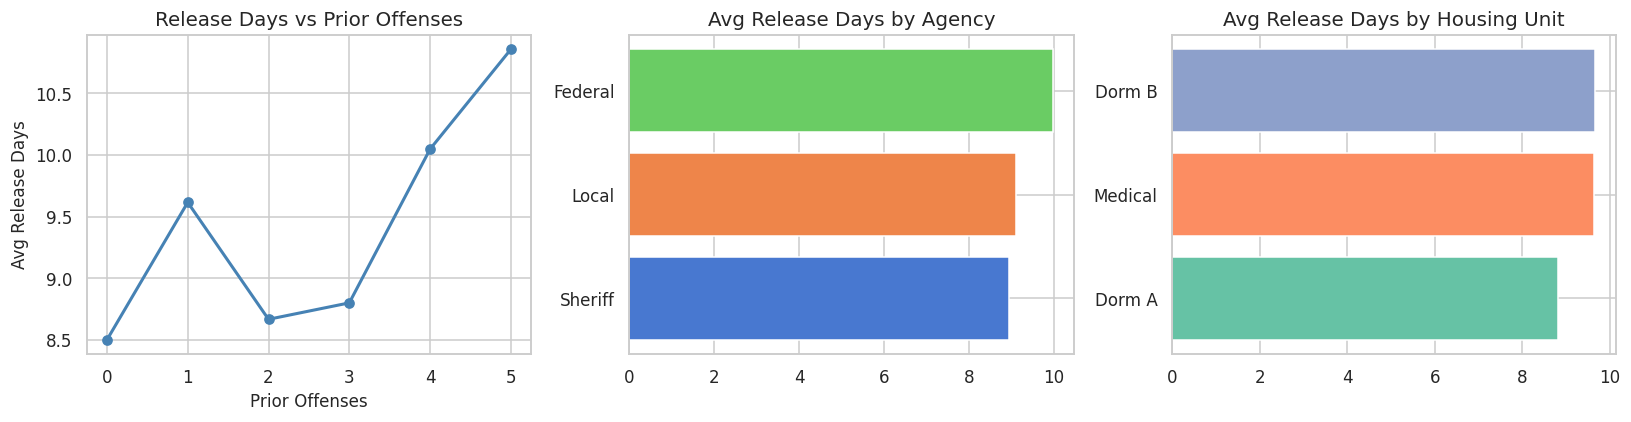

In [6]:
# Prior offenses, agency, and housing analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

prior_avg = df.groupby('prior_offenses')['release_days'].mean()
axes[0].plot(prior_avg.index, prior_avg.values, marker='o', color='steelblue', lw=2)
axes[0].set_title('Release Days vs Prior Offenses')
axes[0].set_xlabel('Prior Offenses'); axes[0].set_ylabel('Avg Release Days')

agency_avg = df.groupby('agency')['release_days'].mean().sort_values()
axes[1].barh(agency_avg.index, agency_avg.values, color=sns.color_palette("muted",3), edgecolor='white')
axes[1].set_title('Avg Release Days by Agency')

housing_avg = df.groupby('housing_unit')['release_days'].mean().sort_values()
axes[2].barh(housing_avg.index, housing_avg.values, color=sns.color_palette("Set2",3), edgecolor='white')
axes[2].set_title('Avg Release Days by Housing Unit')

plt.tight_layout()
plt.savefig('../diagrams/nb1_features.png', bbox_inches='tight')
plt.show()


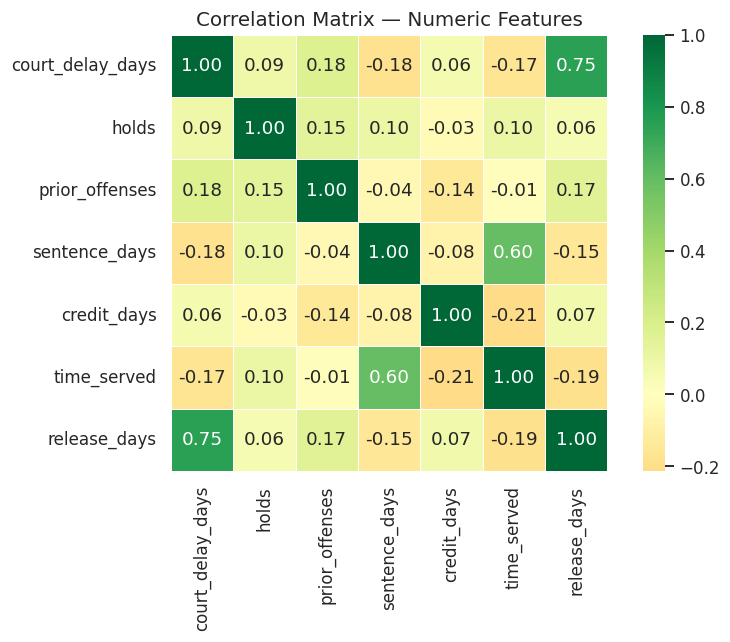

In [7]:
# Correlation heatmap — numeric features
num_cols = ['court_delay_days','holds','prior_offenses','sentence_days',
            'credit_days','time_served','release_days']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('../diagrams/nb1_correlation.png', bbox_inches='tight')
plt.show()


## 3. Feature Engineering

In [8]:
# Encode categorical features
le = {}
cat_cols = ['charge_type', 'county', 'housing_unit', 'custody_level', 'agency', 'release_type']
df_model = df.copy()

for col in cat_cols:
    le[col] = LabelEncoder()
    df_model[col+'_enc'] = le[col].fit_transform(df_model[col])
    print(f"{col}: {dict(zip(le[col].classes_, le[col].transform(le[col].classes_)))}")

FEATURES = ['court_delay_days', 'holds', 'prior_offenses', 'sentence_days',
            'credit_days', 'time_served',
            'charge_type_enc', 'county_enc', 'housing_unit_enc',
            'custody_level_enc', 'agency_enc', 'release_type_enc']
TARGET = 'release_days'

X = df_model[FEATURES]; y = df_model[TARGET]
print(f"\nFeature matrix: {X.shape} | Target: {y.shape}")


charge_type: {'Felony': np.int64(0), 'Misdemeanor': np.int64(1)}
county: {'Boone': np.int64(0), 'Fayette': np.int64(1), 'Jefferson': np.int64(2), 'Kenton': np.int64(3)}
housing_unit: {'Dorm A': np.int64(0), 'Dorm B': np.int64(1), 'Medical': np.int64(2)}
custody_level: {'Max': np.int64(0), 'Medium': np.int64(1), 'Min': np.int64(2)}
agency: {'Federal': np.int64(0), 'Local': np.int64(1), 'Sheriff': np.int64(2)}
release_type: {'Completion': np.int64(0), 'Parole': np.int64(1), 'Transfer': np.int64(2)}

Feature matrix: (100, 12) | Target: (100,)


In [9]:
# Train/test split + scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")


Train: 80 | Test: 20


## 4. Model Training & Evaluation
Four models are trained and compared using MAE, RMSE, and R²:
- **Linear Regression** — interpretable baseline
- **Ridge Regression** — regularized linear model
- **Random Forest** — ensemble of decision trees
- **XGBoost** — gradient boosted trees


In [10]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds  = model.predict(X_te)
    mae    = mean_absolute_error(y_te, preds)
    rmse   = np.sqrt(mean_squared_error(y_te, preds))
    r2     = r2_score(y_te, preds)
    cv     = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')
    print(f"  {name:20s} MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}  CV-R²={cv.mean():.3f}±{cv.std():.3f}")
    return {'Model':name,'MAE':round(mae,3),'RMSE':round(rmse,3),'R²':round(r2,3),
            'CV R²':round(cv.mean(),3),'_model':model,'_preds':preds}

print("Training models...")
results = [
    evaluate('Linear Regression', LinearRegression(),
             X_train_sc, y_train, X_test_sc, y_test),
    evaluate('Ridge Regression',  Ridge(alpha=1.0),
             X_train_sc, y_train, X_test_sc, y_test),
    evaluate('Random Forest',
             RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
             X_train, y_train, X_test, y_test),
    evaluate('XGBoost',
             XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                          subsample=0.8, random_state=42, verbosity=0),
             X_train, y_train, X_test, y_test),
]
print("\n✅ All models trained")


Training models...
  Linear Regression    MAE=2.190  RMSE=2.515  R²=0.662  CV-R²=0.326±0.227
  Ridge Regression     MAE=2.193  RMSE=2.521  R²=0.660  CV-R²=0.335±0.221


  Random Forest        MAE=2.183  RMSE=2.596  R²=0.640  CV-R²=0.256±0.269
  XGBoost              MAE=2.085  RMSE=2.524  R²=0.659  CV-R²=0.242±0.160

✅ All models trained


## 5. Model Comparison

,Model,MAE,RMSE,R²,CV R²
0,Linear Regression,2.190,2.515,0.662,0.326
1,Ridge Regression,2.193,2.521,0.660,0.335
2,XGBoost,2.085,2.524,0.659,0.242
3,Random Forest,2.183,2.596,0.640,0.256


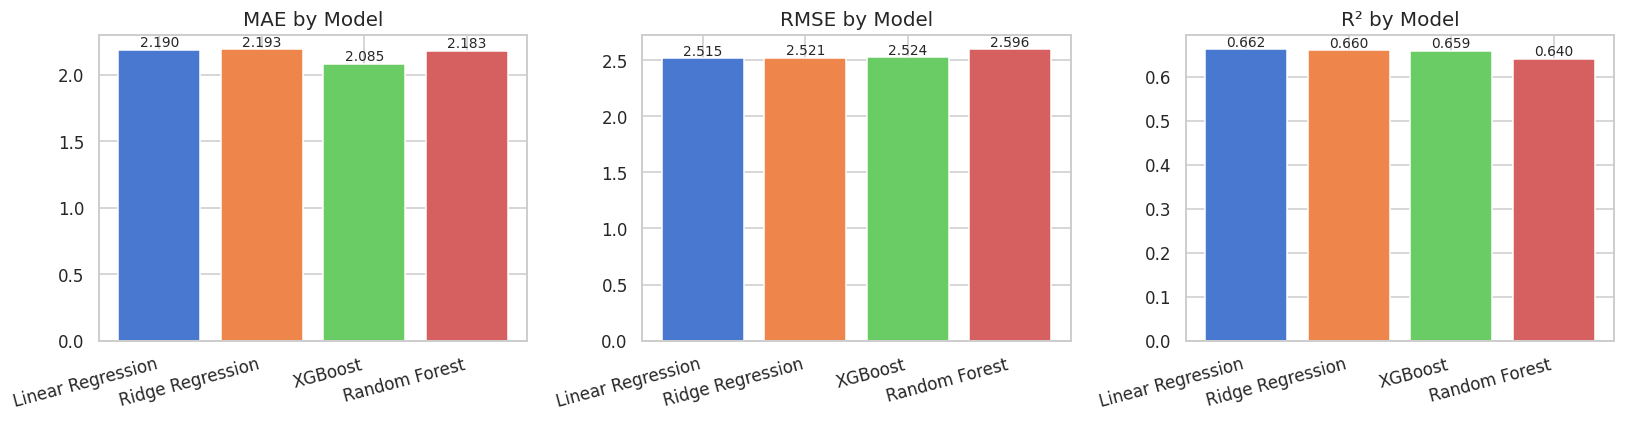

In [11]:
metrics_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                           for r in results]).sort_values('R²', ascending=False).reset_index(drop=True)
display(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = sns.color_palette("muted", 4)
for ax, metric in zip(axes, ['MAE','RMSE','R²']):
    vals = [next(r[metric] for r in results if r['Model']==m) for m in metrics_df['Model']]
    bars = ax.bar(metrics_df['Model'], vals, color=colors, edgecolor='white')
    ax.set_title(f'{metric} by Model'); ax.set_xticklabels(metrics_df['Model'], rotation=15, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../diagrams/nb1_model_comparison.png', bbox_inches='tight')
plt.show()


Best Model: Linear Regression | R²=0.662 | MAE=2.19 | RMSE=2.515


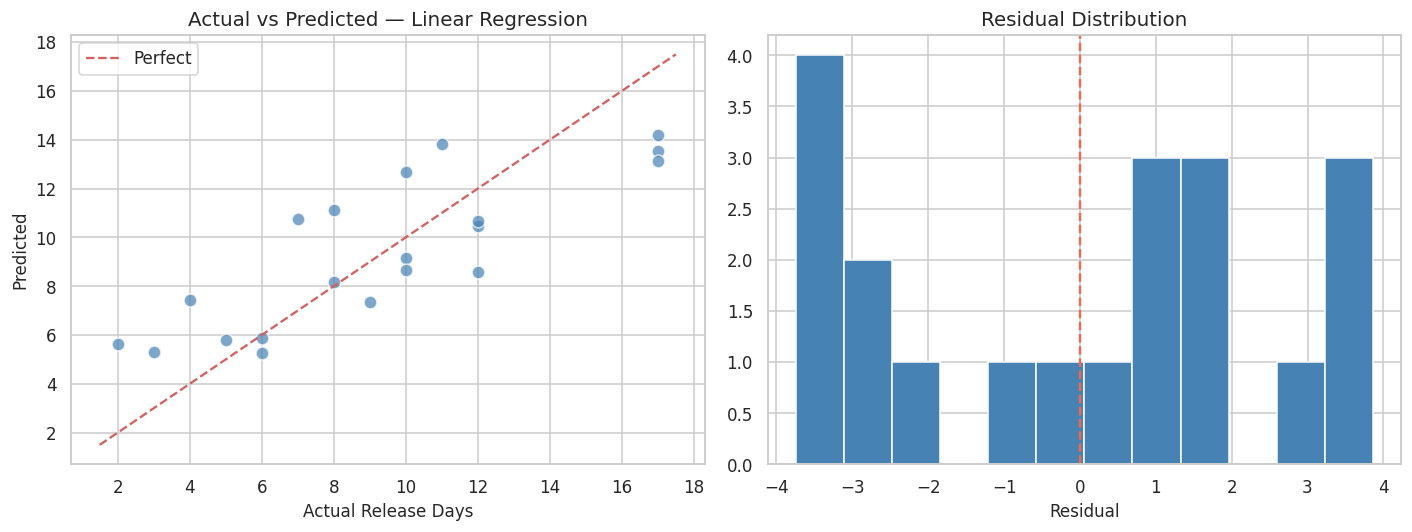

In [12]:
# Actual vs predicted — best model
best = max(results, key=lambda r: r['R²'])
print(f"Best Model: {best['Model']} | R²={best['R²']} | MAE={best['MAE']} | RMSE={best['RMSE']}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
preds = best['_preds']
axes[0].scatter(y_test, preds, alpha=0.7, color='steelblue', edgecolors='white', s=70)
lims = [min(y_test.min(), preds.min())-0.5, max(y_test.max(), preds.max())+0.5]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect'); axes[0].legend()
axes[0].set_xlabel('Actual Release Days'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Actual vs Predicted — {best["Model"]}')

residuals = y_test.values - preds
axes[1].hist(residuals, bins=12, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='tomato', linestyle='--', lw=1.5)
axes[1].set_title('Residual Distribution'); axes[1].set_xlabel('Residual')
plt.tight_layout()
plt.savefig('../diagrams/nb1_actual_vs_predicted.png', bbox_inches='tight')
plt.show()


## 6. Feature Importance

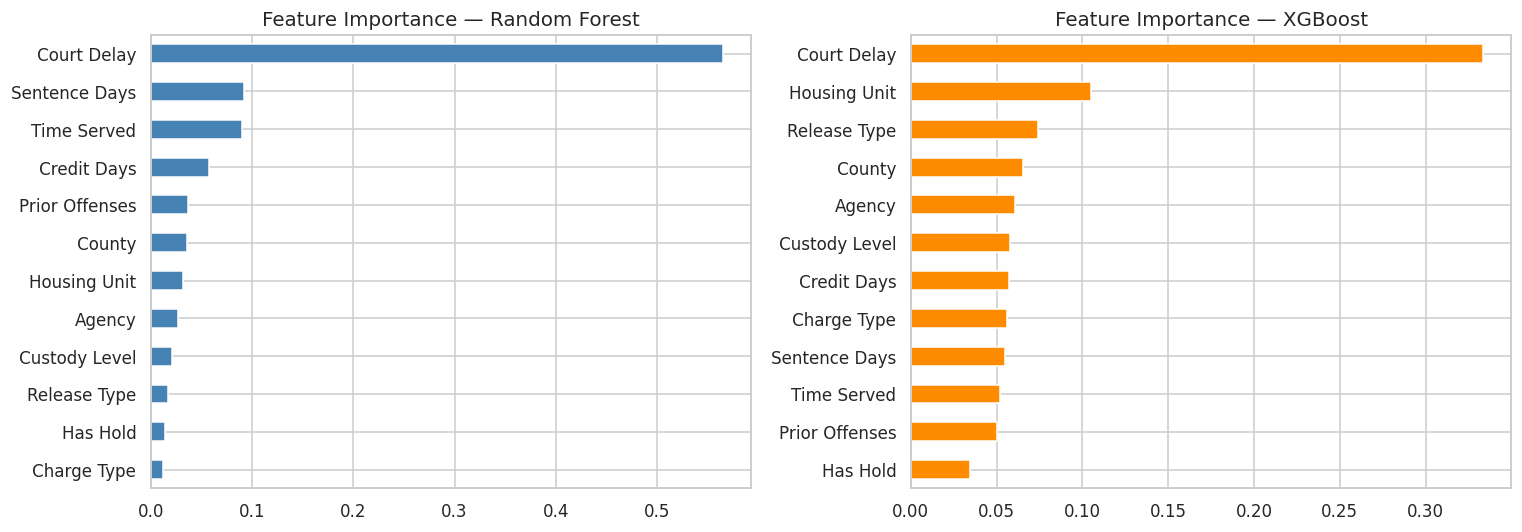

In [13]:
feature_labels = ['Court Delay','Has Hold','Prior Offenses','Sentence Days',
                  'Credit Days','Time Served','Charge Type','County',
                  'Housing Unit','Custody Level','Agency','Release Type']

rf  = next(r['_model'] for r in results if r['Model']=='Random Forest')
xgb = next(r['_model'] for r in results if r['Model']=='XGBoost')

fi_rf  = pd.Series(rf.feature_importances_,  index=feature_labels).sort_values()
fi_xgb = pd.Series(xgb.feature_importances_, index=feature_labels).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fi_rf.plot(kind='barh',  ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Feature Importance — Random Forest')
fi_xgb.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig('../diagrams/nb1_feature_importance.png', bbox_inches='tight')
plt.show()


## 7. Key Insights & Policy Impact

### Model Results
The best-performing model was evaluated on a 20% held-out test set with 5-fold cross-validation on training data.

### Key Findings
- **Court delay days** and **time already served** are consistently the strongest predictors of total release duration.
- **Maximum custody** inmates show longer average release times, reflecting complex processing requirements.
- **Federal agency** bookings trend longer than local or sheriff bookings.
- Inmates with **prior offenses** show a gradual increase in release duration.

### Operational Impact
This model can be deployed at booking intake to:
1. **Flag high-duration cases early** for expedited court scheduling
2. **Allocate housing units** proactively based on predicted stay
3. **Generate daily capacity forecasts** for jail administrators

### Ethical Considerations
> ⚠️ **Bias & Fairness Notice:** Predictive models in criminal justice carry documented risks of amplifying systemic inequities. This model should be used as a *decision-support tool only* — not as grounds for extending detention. Outputs should be regularly audited for disparate impact across demographic groups. This project acknowledges the criticisms raised around systems such as COMPAS and advocates for transparent, human-overseen use of all predictive tools in correctional settings.

---
*Esther Ali | Louisville Metro Department of Corrections | M.S. Business Analytics, UofL*
